In [1]:
!pip install pyspark pillow pandas matplotlib seaborn exifread


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Image Metadata EDA") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/20 12:59:49 WARN Utils: Your hostname, Bhavyasrees-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.76 instead (on interface en0)
26/03/20 12:59:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 12:59:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
import os
from PIL import Image
from PIL.ExifTags import TAGS
import pandas as pd

def extract_metadata(image_path):
    data = {
        "file_name": os.path.basename(image_path),
        "format": None,
        "width": None,
        "height": None,
        "datetime": None,
        "camera_model": None
    }
    
    try:
        img = Image.open(image_path)
        data["format"] = img.format
        data["width"], data["height"] = img.size
        
        exif_data = img._getexif()
        
        if exif_data:
            for tag, value in exif_data.items():
                tag_name = TAGS.get(tag, tag)
                
                if tag_name == "DateTime":
                    data["datetime"] = value
                elif tag_name == "Model":
                    data["camera_model"] = value
                    
    except Exception as e:
        pass
    
    return data

In [17]:
image_folder =  "/Users/BhavyasreeKondi/Downloads/input_photos"

metadata_list = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            metadata_list.append(extract_metadata(path))

df = pd.DataFrame(metadata_list)
df.head()

""


In [20]:
import os

print(image_folder)
print(os.path.exists(image_folder))

/Users/BhavyasreeKondi/Downloads/input_photos
False


In [21]:
image_folder = "/Users/Bhavyasree/Downloads/input_photos"

In [11]:
print(os.listdir(image_folder))

['IMG_9323.HEIC', 'IMG_7960.JPG', 'IMG_3684.HEIC', 'IMG_4141.HEIC', 'a1d39914a2b445eca0d14e44c63ce49d.mov', 'filtered-735FF129-451C-45AE-A76F-6D7DA129CBCE.mp4', 'IMG_5300.HEIC', 'IMG_0552.HEIC', 'IMG_8162.HEIC', 'IMG_4454.HEIC', 'IMG_6469.HEIC', 'IMG_6193.HEIC', 'IMG_0799.JPG', 'ff9d058a-133c-4b29-94df-02827af3a4b2.jpg', 'F9698DCD-DAEE-46FB-AF45-6080CED78ACF.mp4', 'IMG_3811.HEIC', 'IMG_2353.HEIC', 'IMG_6740.HEIC', '20200913_101031.jpg', 'IMG_3407.HEIC', 'recorded-17786619472310.mp4', 'IMG_2646.HEIC', 'IMG_6828.HEIC', 'IMG_4456.MP4', '04D52997-78F0-4685-B642-C62DA9734D88.jpg', 'IMG_2884.HEIC', 'IMG_3796.HEIC', 'IMG_9231.heic', '5c575377-2677-47ce-9614-78fe30551c56.jpg', '5AB18219-D529-456F-9900-6E26980C7825.mp4', 'IMG_6717.HEIC', 'IMG_0216.JPG', 'IMG_3450.HEIC', '20200906_115417.jpg', 'IMG_8089.heic', 'a9f14756-bd48-48f4-b538-9659c1eb87c6.mp4', 'IMG_4845.JPG', 'IMG_0631(1).HEIC', 'IMG_0905.HEIC', 'IMG_7540.HEIC', 'IMG_0362.JPG', 'IMG_3446.HEIC', 'IMG_0544.HEIC', 'IMG_2129.HEIC', 'IMG_36

In [12]:
for root, dirs, files in os.walk(image_folder):
    print("FOLDER:", root)
    print("FILES:", files[:5])
    break

FOLDER: /Users/Bhavyasree/Downloads/input_photos
FILES: ['IMG_9323.HEIC', 'IMG_7960.JPG', 'IMG_3684.HEIC', 'IMG_4141.HEIC', 'a1d39914a2b445eca0d14e44c63ce49d.mov']


In [22]:
metadata_list = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            try:
                meta = extract_metadata(path)
                metadata_list.append(meta)
            except Exception as e:
                print("Error:", file)

In [23]:
df = pd.DataFrame(metadata_list)

print("Total images processed:", len(df))
df.head()

Total images processed: 745


,file_name,format,width,height,datetime,camera_model
0,IMG_7960.JPG,JPEG,1242,2208,None,None
1,IMG_0799.JPG,JPEG,1188,2208,None,None
2,ff9d058a-133c-4b29-94df-02827af3a4b2.jpg,JPEG,1600,1200,None,None
3,20200913_101031.jpg,JPEG,3264,1472,2020:09:13 10:10:31,SM-A515F
4,04D52997-78F0-4685-B642-C62DA9734D88.jpg,JPEG,3840,2160,2023:04:23 16:44:24,iPhone 12 Pro Max


In [31]:
df_full = pd.DataFrame(metadata_list)  # original full data

In [32]:
df_full["resolution"] = df_full["width"] * df_full["height"]

In [33]:
df_full = df_full.dropna(subset=["width", "height"])
df_full["resolution"] = df_full["width"] * df_full["height"]

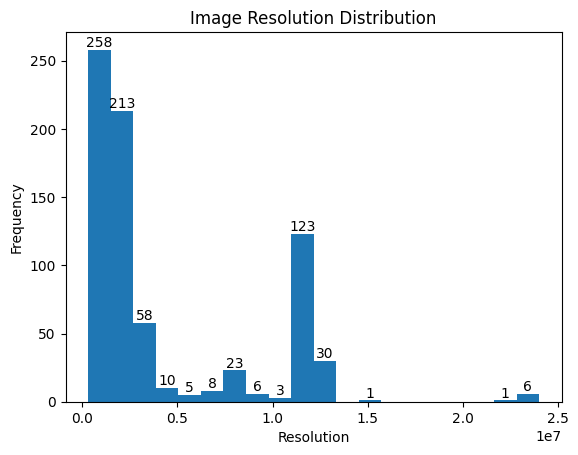

In [43]:
import matplotlib.pyplot as plt

counts, bins, patches = plt.hist(df_full["resolution"], bins=20)

# Add labels on top of each bar
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            int(count),
            ha='center',
            va='bottom'
        )

plt.title("Image Resolution Distribution")
plt.xlabel("Resolution")
plt.ylabel("Frequency")
plt.show()

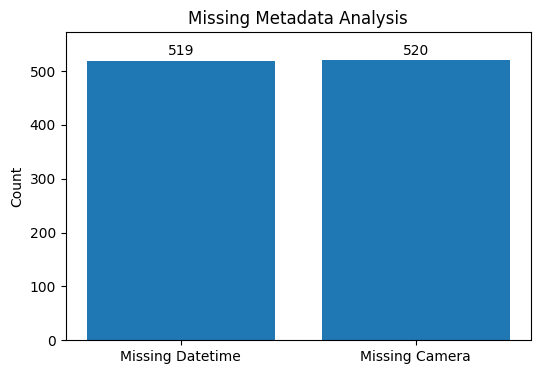

In [44]:
plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,  # small offset so text is above bar
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Missing Metadata Analysis")
plt.ylabel("Count")
plt.ylim(0, max(values) * 1.1)  # add space for labels
plt.show()

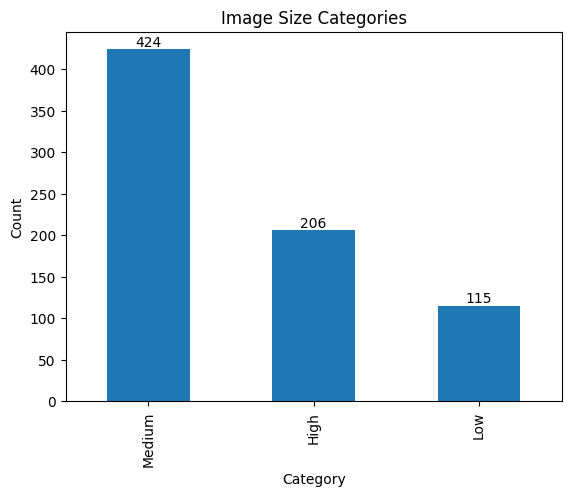

In [46]:
import matplotlib.pyplot as plt

def categorize(res):
    if res < 1_000_000:
        return "Low"
    elif res < 5_000_000:
        return "Medium"
    else:
        return "High"

df_full["size_category"] = df_full["resolution"].apply(categorize)

counts = df_full["size_category"].value_counts()

bars = counts.plot(kind='bar')

# Add labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Image Size Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

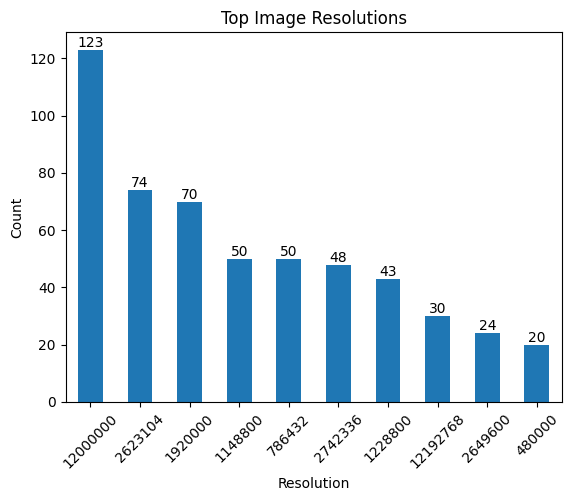

In [47]:

df_full["resolution"] = df_full["width"] * df_full["height"]

top_res = df_full["resolution"].value_counts().head(10)

bars = top_res.plot(kind='bar')

# Add labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Top Image Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

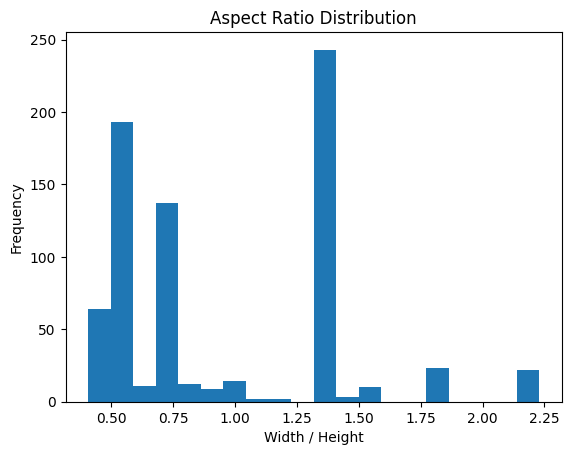

In [41]:
df_full["aspect_ratio"] = df_full["width"] / df_full["height"]

plt.hist(df_full["aspect_ratio"], bins=20)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Frequency")
plt.show()

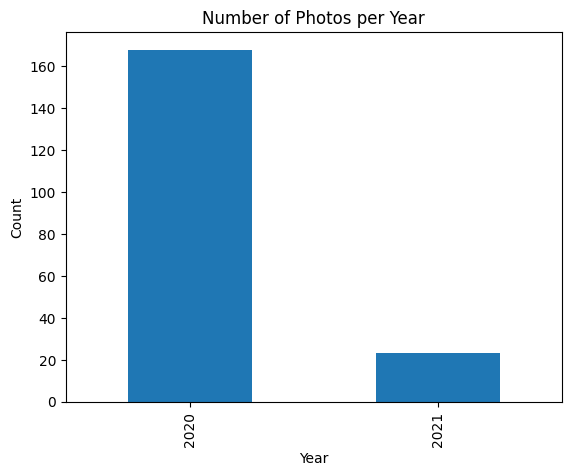

In [42]:
import re

def extract_date(name):
    match = re.search(r'(\d{8})', name)
    if match:
        return match.group(1)
    return None

df_full["date_from_name"] = df_full["file_name"].apply(extract_date)

df_full["date_from_name"] = pd.to_datetime(
    df_full["date_from_name"],
    format="%Y%m%d",
    errors="coerce"
)
df_time = df_full.dropna(subset=["date_from_name"]).copy()

df_time["year"] = df_time["date_from_name"].dt.year

year_counts = df_time["year"].value_counts().sort_index()

year_counts.plot(kind='bar')
plt.title("Number of Photos per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()